In [1]:
import warnings
from pathlib import Path
import echopype as ep  # we recommend using "ep"
import xarray as xr
import hvplot.xarray  # for interactive plots
import matplotlib.pyplot as plt

In [2]:
file_name_raw = "261002_01_env test.raw"
raw_path = rf"P:\11212489-008-acoustic-ch4-test\EK80\Data\{file_name_raw}"
output_path = r"P:\11212489-008-acoustic-ch4-test\data_processing\converted_files"

In [3]:
ed = ep.open_raw(
    raw_path,
    sonar_model="EK80",
)

In [4]:
filename = raw_path.split("\\")[-1].split(".")[0]
ed.to_netcdf(save_path=f"{output_path}/{filename}.nc")  # save to FILENAME.nc in the folder unpacked_files

### Calibration

In [5]:
nc_path = f'{output_path}/{filename}.nc'   # path to a converted nc file
echodata = ep.open_converted(nc_path)      # create an EchoData object


In [6]:
ds_Sv = ep.calibrate.compute_Sv(ed, waveform_mode="CW", encode_mode="complex")

In [9]:
ds_Sv['channel'].values

array(['WBT Tube 291337-15 ES120-7CD_ES'], dtype='<U31')

In [11]:
ch = 'WBT Tube 291337-15 ES120-7CD_ES'

da = ds_Sv["Sv"].sel(channel=ch, drop=True)          # Sv for one channel

print("Sv dims:", da.dims)
print("Sv sizes:", da.sizes)


Sv dims: ('ping_time', 'range_sample')
Sv sizes: Frozen({'ping_time': 3215, 'range_sample': 1133})


In [ ]:
list_params = {
    "sound_speed": ds_Sv.sound_speed.values,
    "receiver_sampling_frequency": ds_Sv.receiver_sampling_frequency.values,
    "channel": ds_Sv.channel.values,
    "pressure": ds_Sv.pressure.values,
    "temperature": ds_Sv.temperature.values,
    "salinity": ds_Sv.salinity.values
    
}

print(list_params)

{'sound_speed': array(1482.34332), 'receiver_sampling_frequency': array([1500000.]), 'channel': array(['WBT Tube 291337-15 ES120-7CD_ES'], dtype='<U31'), 'pressure': array(2.), 'temperature': array(20.), 'salinity': array(0.)}


In [30]:
ds_Sv.Sv

<xarray.DataArray 'Sv' (channel: 1, ping_time: 3215, range_sample: 1133)> Size: 29MB
array([[[         nan,          nan,          nan, ..., -19.90721249,
         -20.16473356, -20.86365507],
        [         nan,          nan,          nan, ...,          nan,
                  nan,          nan],
        [         nan,          nan,          nan, ...,          nan,
                  nan,          nan],
        ...,
        [         nan,          nan,          nan, ...,          nan,
                  nan,          nan],
        [         nan,          nan,          nan, ...,          nan,
                  nan,          nan],
        [         nan,          nan,          nan, ...,          nan,
                  nan,          nan]]], shape=(1, 3215, 1133))
Coordinates:
  * channel       (channel) <U31 124B 'WBT Tube 291337-15 ES120-7CD_ES'
  * ping_time     (ping_time) datetime64[ns] 26kB 2026-10-02T11:34:08.836535 ...
  * range_sample  (range_sample) int64 9kB 0 1 2 3 4 ... 1129 1130 1131 1132
Attributes:
    long_name:      Volume backscattering strength (Sv re 1 m-1)
    units:          dB
    waveform_mode:  CW
    encode_mode:    complex

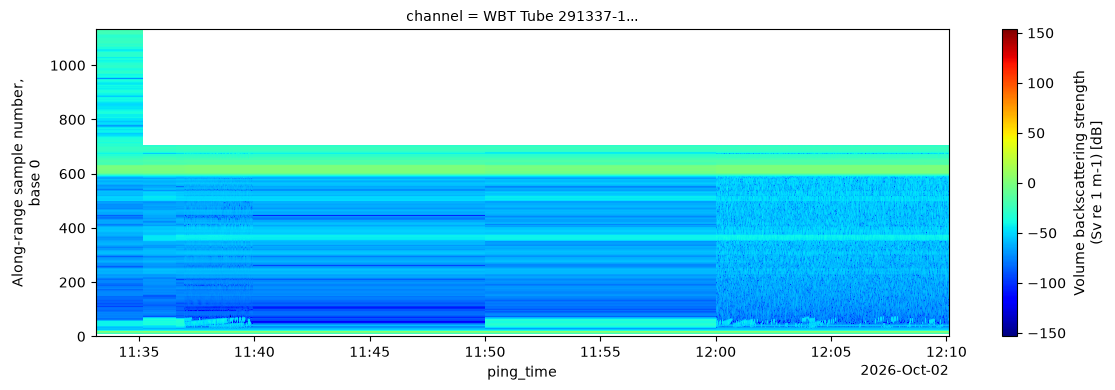

In [28]:
import echopype.colormap  # make custom colormap available

# Plot all 3 channels for inspection
ds_Sv["Sv"].plot(
    x="ping_time",
    y="range_sample",
    row="channel",
    figsize=(12, 4),
    cmap='jet'  # use the custom EK500 colormap
)